<a href="https://colab.research.google.com/github/gmauricio-toledo/tda/blob/main/notebooks/06-Vectorizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Vectorización de Diagramas de Persistencia</h1>

<h3>Comparación de Métodos: Betti Curves, Landscapes, Images, Entropy, Amplitudes</h3>

In [1]:
!pip install -U giotto-tda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not cur

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Conjuntos de datos

Funciones para generar los conjuntos de datos

In [2]:
def generate_circle(n_points=100, radius=1.0, noise=0.05, random_state=None):
    """Círculo con ruido gaussiano"""
    if random_state is not None:
        np.random.seed(random_state)

    theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)

    points = np.column_stack([x, y])
    points += np.random.normal(0, noise, points.shape)

    return points

def generate_ellipse(n_points=100, a=2.0, b=1.0, noise=0.05, random_state=None):
    """Elipse (a=eje mayor, b=eje menor)"""
    if random_state is not None:
        np.random.seed(random_state)

    theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    x = a * np.cos(theta)
    y = b * np.sin(theta)

    points = np.column_stack([x, y])
    points += np.random.normal(0, noise, points.shape)

    return points

def generate_figure_eight(n_points=100, radius=1.0, noise=0.05, random_state=None):
    """Figura 8 (dos círculos tangentes)"""
    if random_state is not None:
        np.random.seed(random_state)

    # Círculo superior
    n_upper = n_points // 2
    theta_upper = np.linspace(0, 2*np.pi, n_upper, endpoint=False)
    x_upper = radius * np.cos(theta_upper)
    y_upper = radius * np.sin(theta_upper) + radius

    # Círculo inferior
    n_lower = n_points - n_upper
    theta_lower = np.linspace(0, 2*np.pi, n_lower, endpoint=False)
    x_lower = radius * np.cos(theta_lower)
    y_lower = radius * np.sin(theta_lower) - radius

    points = np.vstack([
        np.column_stack([x_upper, y_upper]),
        np.column_stack([x_lower, y_lower])
    ])
    points += np.random.normal(0, noise, points.shape)

    return points

def generate_three_circles(n_points=120, radius=0.5, noise=0.05, random_state=None):
    """Tres círculos separados (triángulo de círculos)"""
    if random_state is not None:
        np.random.seed(random_state)

    n_per_circle = n_points // 3

    # Centros en triángulo equilátero
    centers = np.array([
        [0, 2],
        [-1.7, -1],
        [1.7, -1]
    ])

    all_points = []
    for center in centers:
        theta = np.linspace(0, 2*np.pi, n_per_circle, endpoint=False)
        x = center[0] + radius * np.cos(theta)
        y = center[1] + radius * np.sin(theta)
        all_points.append(np.column_stack([x, y]))

    points = np.vstack(all_points)
    points += np.random.normal(0, noise, points.shape)

    return points

def generate_square(n_points=100, side=2.0, noise=0.05, random_state=None):
    """Cuadrado (perímetro)"""
    if random_state is not None:
        np.random.seed(random_state)

    n_per_side = n_points // 4

    # Cuatro lados
    top = np.column_stack([
        np.linspace(-side/2, side/2, n_per_side),
        np.ones(n_per_side) * side/2
    ])
    right = np.column_stack([
        np.ones(n_per_side) * side/2,
        np.linspace(side/2, -side/2, n_per_side)
    ])
    bottom = np.column_stack([
        np.linspace(side/2, -side/2, n_per_side),
        np.ones(n_per_side) * (-side/2)
    ])
    left = np.column_stack([
        np.ones(n_points - 3*n_per_side) * (-side/2),
        np.linspace(-side/2, side/2, n_points - 3*n_per_side)
    ])

    points = np.vstack([top, right, bottom, left])
    points += np.random.normal(0, noise, points.shape)

    return points






Clase 0: Círculo
  Generadas 20 muestras

Clase 1: Elipse
  Generadas 20 muestras

Clase 2: Figura 8
  Generadas 20 muestras

Clase 3: Tres Círculos
  Generadas 20 muestras

Clase 4: Cuadrado
  Generadas 20 muestras

──────────────────────────────────────────────────────────────────────
Total dataset shape: (100, 99, 2)
Labels shape: (100,)
Clases: [0 1 2 3 4]
Muestras por clase: [20 20 20 20 20]


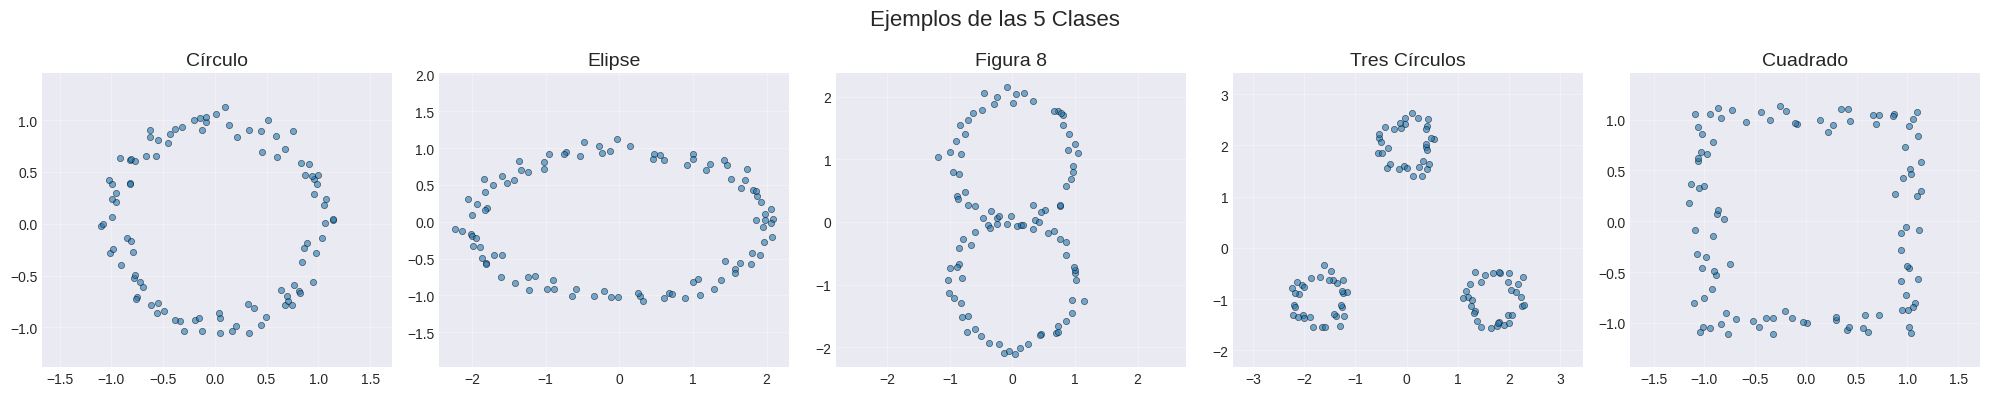

In [3]:
n_samples_per_class = 20
n_points = 99
noise_level = 0.08

dataset_generators = {
    0: ('Círculo', generate_circle),
    1: ('Elipse', generate_ellipse),
    2: ('Figura 8', generate_figure_eight),
    3: ('Tres Círculos', generate_three_circles),
    4: ('Cuadrado', generate_square)
}

# Generar todas las muestras
point_clouds = []
labels = []
class_names = []

for class_id, (class_name, generator) in dataset_generators.items():
    class_names.append(class_name)
    print(f"\nClase {class_id}: {class_name}")

    for i in range(n_samples_per_class):
        if class_name == 'Círculo':
            pc = generator(n_points=n_points, noise=noise_level, random_state=class_id*100 + i)
        elif class_name == 'Elipse':
            pc = generator(n_points=n_points, noise=noise_level, random_state=class_id*100 + i)
        elif class_name == 'Figura 8':
            pc = generator(n_points=n_points, noise=noise_level, random_state=class_id*100 + i)
        elif class_name == 'Tres Círculos':
            pc = generator(n_points=n_points, noise=noise_level, random_state=class_id*100 + i)
        else:  # Cuadrado
            pc = generator(n_points=n_points, noise=noise_level, random_state=class_id*100 + i)

        point_clouds.append(pc)
        labels.append(class_id)

    print(f"  Generadas {n_samples_per_class} muestras")

X = np.array(point_clouds)
y = np.array(labels)

print(f"\n{'─'*70}")
print(f"Total dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Clases: {np.unique(y)}")
print(f"Muestras por clase: {np.bincount(y)}")

# Visualizar ejemplos
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for class_id, (class_name, _) in dataset_generators.items():
    # Primera muestra de cada clase
    sample_idx = np.where(y == class_id)[0][0]
    sample = X[sample_idx]

    axes[class_id].scatter(sample[:, 0], sample[:, 1],
                          alpha=0.6, s=20, edgecolors='black', linewidth=0.5)
    axes[class_id].set_title(f'{class_name}', fontsize=14)
    axes[class_id].axis('equal')
    axes[class_id].grid(True, alpha=0.3)

plt.suptitle('Ejemplos de las 5 Clases', fontsize=16)
plt.tight_layout()
plt.show()

# Homología Persistente


Tiempo de cómputo: 20.74 segundos
 Diagrams shape: (100, 116, 3)
   (100 muestras, 116 features máximo, 3 valores)


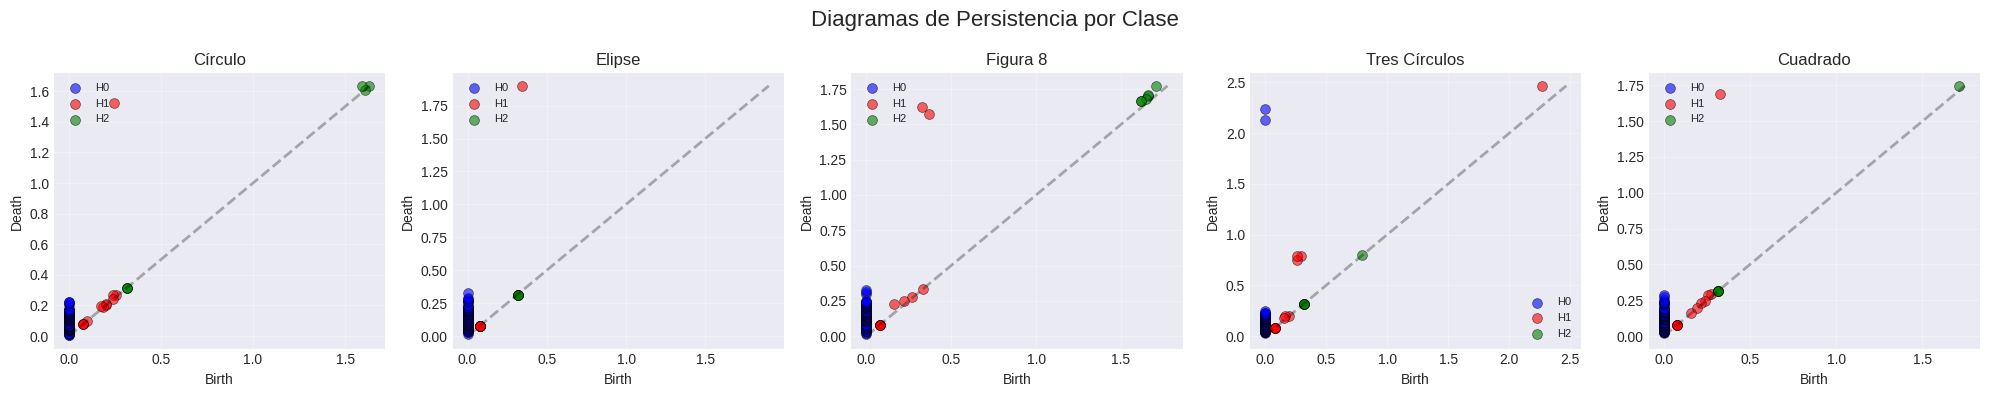


──────────────────────────────────────────────────────────────────────
ANÁLISIS DE FEATURES TOPOLÓGICOS POR CLASE
──────────────────────────────────────────────────────────────────────

Círculo:
  H1 features persistentes (>0.2): media=1.0, std=0.00

Elipse:
  H1 features persistentes (>0.2): media=1.0, std=0.00

Figura 8:
  H1 features persistentes (>0.2): media=2.0, std=0.00

Tres Círculos:
  H1 features persistentes (>0.2): media=3.4, std=0.48

Cuadrado:
  H1 features persistentes (>0.2): media=1.0, std=0.00


In [4]:
from gtda.homology import VietorisRipsPersistence
import time

# Configurar VR
vr = VietorisRipsPersistence(
    homology_dimensions=[0, 1, 2],
    max_edge_length=3.0,
    n_jobs=-1  # Usar todos los cores
)

# Calcular
start_time = time.time()
diagrams = vr.fit_transform(X)
elapsed = time.time() - start_time

print(f"\nTiempo de cómputo: {elapsed:.2f} segundos")
print(f" Diagrams shape: {diagrams.shape}")
print(f"   ({diagrams.shape[0]} muestras, {diagrams.shape[1]} features máximo, 3 valores)")

# Visualizar diagramas de ejemplo (uno por clase)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for class_id, class_name in enumerate(class_names):
    # Primera muestra de cada clase
    sample_idx = np.where(y == class_id)[0][0]
    dgm = diagrams[sample_idx]

    ax = axes[class_id]

    # Separar por dimensión homológica
    for dim in [0, 1, 2]:
        dgm_dim = dgm[dgm[:, 2] == dim]
        if len(dgm_dim) > 0:
            births = dgm_dim[:, 0]
            deaths = dgm_dim[:, 1]

            colors = {0: 'blue', 1: 'red', 2: 'green'}
            labels = {0: 'H0', 1: 'H1', 2: 'H2'}

            ax.scatter(births, deaths,
                      alpha=0.6, s=50,
                      color=colors[dim],
                      label=labels[dim],
                      edgecolors='black', linewidth=0.5)

    # Diagonal
    max_val = dgm[:, 1].max() if len(dgm) > 0 else 1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=2)

    ax.set_xlabel('Birth', fontsize=10)
    ax.set_ylabel('Death', fontsize=10)
    ax.set_title(class_name, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Diagramas de Persistencia por Clase', fontsize=16)
plt.tight_layout()
plt.show()

# Análisis rápido de features
print(f"\n{'─'*70}")
print("ANÁLISIS DE FEATURES TOPOLÓGICOS POR CLASE")
print(f"{'─'*70}")

for class_id, class_name in enumerate(class_names):
    class_diagrams = diagrams[y == class_id]

    # Contar features H1 persistentes (persistencia > 0.2)
    h1_counts = []
    for dgm in class_diagrams:
        dgm_h1 = dgm[dgm[:, 2] == 1]
        dgm_h1_finite = dgm_h1[np.isfinite(dgm_h1[:, 1])]
        if len(dgm_h1_finite) > 0:
            persistence = dgm_h1_finite[:, 1] - dgm_h1_finite[:, 0]
            persistent_features = np.sum(persistence > 0.2)
            h1_counts.append(persistent_features)
        else:
            h1_counts.append(0)

    print(f"\n{class_name}:")
    print(f"  H1 features persistentes (>0.2): media={np.mean(h1_counts):.1f}, std={np.std(h1_counts):.2f}")

# Métodos de vectorización

## Top-n persistencias


──────────────────────────────────────────────────────────────────────
Top-5 Persistencias
──────────────────────────────────────────────────────────────────────
 Features shape: (100, 15)
   100 muestras × 15 features
   (5 persistencias x 3 dimensiones homológicas)

 Accuracy (5-fold CV):
   Media: 0.930
   Std:   0.051

──────────────────────────────────────────────────────────────────────
Top-10 Persistencias
──────────────────────────────────────────────────────────────────────
 Features shape: (100, 30)
   100 muestras × 30 features
   (10 persistencias x 3 dimensiones homológicas)

 Accuracy (5-fold CV):
   Media: 0.910
   Std:   0.037

──────────────────────────────────────────────────────────────────────
Top-15 Persistencias
──────────────────────────────────────────────────────────────────────
 Features shape: (100, 45)
   100 muestras × 45 features
   (15 persistencias x 3 dimensiones homológicas)

 Accuracy (5-fold CV):
   Media: 0.930
   Std:   0.051

────────────────────

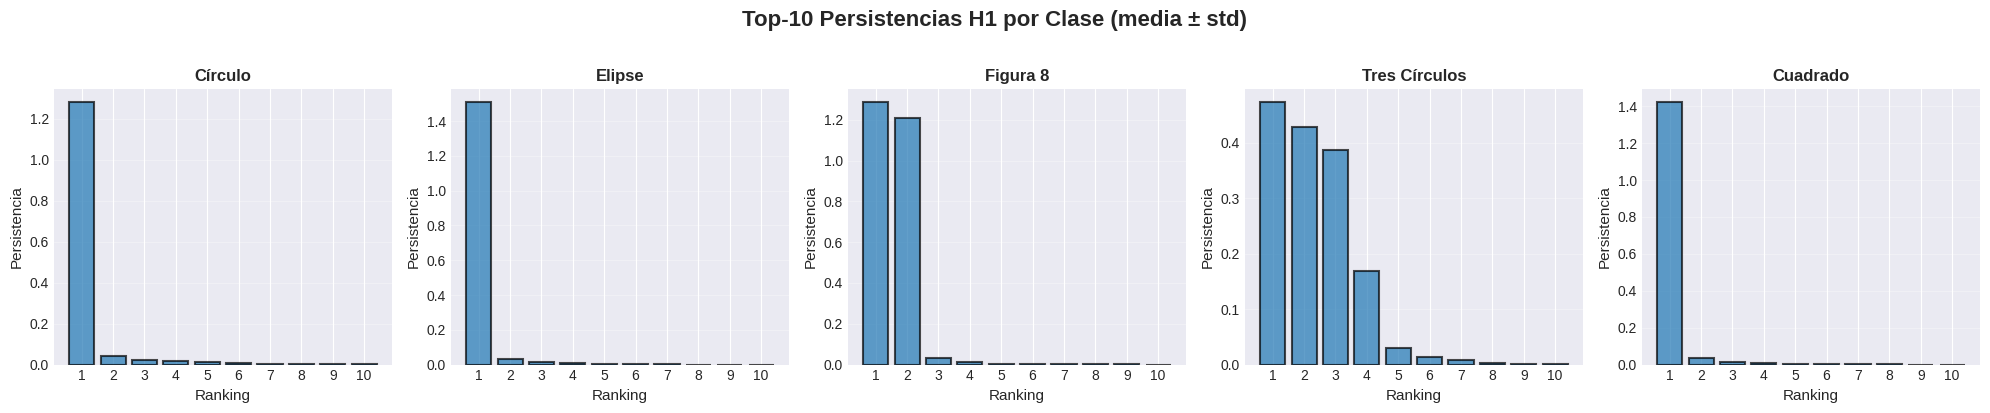


──────────────────────────────────────────────────────────────────────
EFECTO DE N EN ACCURACY
──────────────────────────────────────────────────────────────────────


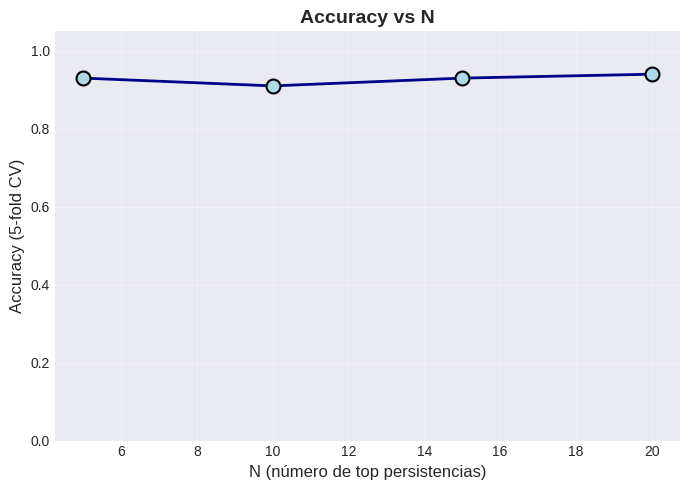


──────────────────────────────────────────────────────────────────────
VISUALIZACIÓN PCA - TOP-10 PERSISTENCIAS
──────────────────────────────────────────────────────────────────────


KeyError: 3

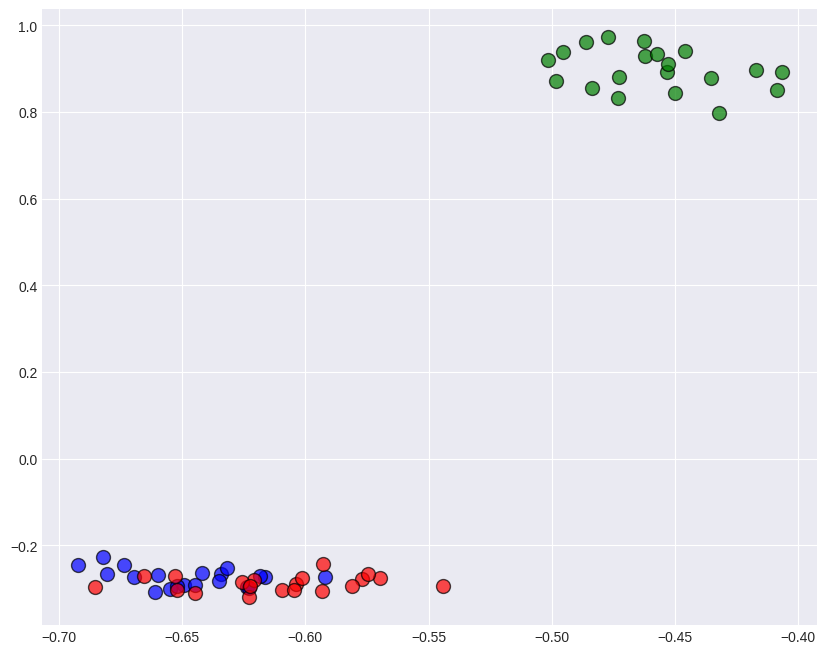

In [18]:
def extract_topn_persistences(diagrams, n_top=10, fill_value=0.0):
    """
    Extrae las top-N persistencias de cada dimensión homológica.

    Parámetros:
    -----------
    diagrams : array-like, shape (n_samples, n_features, 3)
        Diagramas de persistencia (birth, death, dimension)
    n_top : int
        Número de top persistencias a extraer por dimensión
    fill_value : float
        Valor para rellenar si hay menos de n_top features

    Returns:
    --------
    features : array, shape (n_samples, n_top * n_dims)
        Features concatenados: [top_H0, top_H1, top_H2]
    """
    n_samples = len(diagrams)
    n_dims = int(diagrams[:, :, 2].max()) + 1  # H0, H1, H2...

    features = np.zeros((n_samples, n_top * n_dims))

    for i, dgm in enumerate(diagrams):
        for dim in range(n_dims):
            # Filtrar por dimensión
            dgm_dim = dgm[dgm[:, 2] == dim]

            # Calcular persistencias (death - birth)
            # Filtrar infinitos
            finite_mask = np.isfinite(dgm_dim[:, 1])
            dgm_dim_finite = dgm_dim[finite_mask]

            if len(dgm_dim_finite) > 0:
                persistences = dgm_dim_finite[:, 1] - dgm_dim_finite[:, 0]

                # Ordenar de mayor a menor
                sorted_pers = np.sort(persistences)[::-1]

                # Tomar top-N (rellenar con fill_value si hay menos)
                top_pers = np.full(n_top, fill_value)
                n_available = min(n_top, len(sorted_pers))
                top_pers[:n_available] = sorted_pers[:n_available]

                # Guardar en features
                start_idx = dim * n_top
                features[i, start_idx:start_idx + n_top] = top_pers
            else:
                # Si no hay features, dejar en fill_value
                start_idx = dim * n_top
                features[i, start_idx:start_idx + n_top] = fill_value

    return features

# Probar con diferentes valores de N
n_values = [5, 10, 15, 20]
topn_results = {}

for n in n_values:
    print(f"\n{'─'*70}")
    print(f"Top-{n} Persistencias")
    print(f"{'─'*70}")

    # Extraer features
    topn_features = extract_topn_persistences(diagrams, n_top=n, fill_value=0.0)

    print(f" Features shape: {topn_features.shape}")
    print(f"   {topn_features.shape[0]} muestras × {topn_features.shape[1]} features")
    print(f"   ({n} persistencias x 3 dimensiones homológicas)")

    # Clasificación
    clf_topn = RandomForestClassifier(n_estimators=10, random_state=42)
    scores_topn = cross_val_score(clf_topn, topn_features, y, cv=5, scoring='accuracy')

    topn_results[n] = {
        'features': topn_features,
        'scores': scores_topn,
        'mean': scores_topn.mean(),
        'std': scores_topn.std()
    }

    print(f"\n Accuracy (5-fold CV):")
    print(f"   Media: {scores_topn.mean():.3f}")
    print(f"   Std:   {scores_topn.std():.3f}")

# Visualizar distribución de top persistencias por clase
print(f"\n{'─'*70}")
print("ANÁLISIS DE TOP-10 PERSISTENCIAS POR CLASE")
print(f"{'─'*70}")

n_selected = 10
topn_features_selected = topn_results[n_selected]['features']

# Visualizar top persistencias para H₁
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for class_id, class_name in enumerate(class_names):
    ax = axes[class_id]

    # Top-10 persistencias H1 para esta clase (índices 10:20)
    class_topn_h1 = topn_features_selected[y == class_id, 10:20]

    # Promedio por posición (1ra más persistente, 2da, etc.)
    mean_topn = class_topn_h1.mean(axis=0)
    std_topn = class_topn_h1.std(axis=0)

    positions = np.arange(1, 11)
    ax.bar(positions, mean_topn,
        #    yerr=std_topn,
           capsize=4,
        #    color=colors[class_id],
           alpha=0.7,
           edgecolor='black',
           linewidth=1.5)

    ax.set_xlabel('Ranking', fontsize=11)
    ax.set_ylabel('Persistencia', fontsize=11)
    ax.set_title(f'{class_name}', fontweight='bold', fontsize=12)
    ax.set_xticks(positions)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Top-10 Persistencias H1 por Clase (media ± std)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Comparar efecto de N en accuracy, construimos un dataframe
print(f"\n{'─'*70}")
print("EFECTO DE N EN ACCURACY")
print(f"{'─'*70}")

comparison_data = []
for n in n_values:
    comparison_data.append({
        'N': n,
        'Features': n * 3,  # 3 dimensiones homológicas
        'Accuracy': topn_results[n]['mean'],
        'Std': topn_results[n]['std']
    })

comparison_df = pd.DataFrame(comparison_data)
# print("\n" + comparison_df.to_string(index=False))

# Gráfica: N vs Accuracy
plt.figure(figsize=(7, 5))

# Accuracy vs N
plt.errorbar(comparison_df['N'], comparison_df['Accuracy'],
            # yerr=comparison_df['Std'],
            marker='o', markersize=10,
            capsize=5, capthick=2,
            linewidth=2,
            color='darkblue',
            markerfacecolor='lightblue',
            markeredgecolor='black',
            markeredgewidth=1.5)

plt.xlabel('N (número de top persistencias)', fontsize=12)
plt.ylabel('Accuracy (5-fold CV)', fontsize=12)
plt.title('Accuracy vs N', fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

# PCA de Top-10
print(f"\n{'─'*70}")
print("VISUALIZACIÓN PCA - TOP-10 PERSISTENCIAS")
print(f"{'─'*70}")

pca_topn = PCA(n_components=2)
topn_pca = pca_topn.fit_transform(topn_features_selected)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for class_id, class_name in enumerate(class_names):
    mask = y == class_id
    ax.scatter(topn_pca[mask, 0], topn_pca[mask, 1],
              label=class_name,
              color=colors[class_id],
              s=100, alpha=0.7,
              edgecolors='black', linewidth=1)

ax.set_xlabel(f'PC1 ({pca_topn.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_topn.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
ax.set_title('Top-10 Persistencias - PCA', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Curvas de Betti



Las **Betti curves** (curvas de Betti) son funciones que describen cómo evoluciona la topología de un espacio conforme aumenta el parámetro de filtración ε.

Para cada dimensión homológica k, la curva de Betti **βₖ(ε)** cuenta **cuántos features topológicos están "vivos" en ese valor de ε**:

- **β₀(ε)**: número de componentes conexas en VR(X, ε)
- **β₁(ε)**: número de ciclos/hoyos 1-dimensionales
- **β₂(ε)**: número de cavidades/hoyos 2-dimensionales


<h4>Construcción desde el Diagrama de Persistencia</h4>

Dado un diagrama de persistencia D = {(bᵢ, dᵢ)} para dimensión k:

1. Para cada valor de filtración t:
   - Cuenta cuántos features tienen **birth ≤ t** y **death > t**
   - Estos son los features "vivos" en t

2. La función resultante βₖ(t) es la Betti curve para dimensión k

**Ejemplo:**
```
Diagrama H₁: {(0.5, 1.2), (0.8, 2.0), (1.0, 1.5)}

β₁(0.3) = 0  (ningún feature ha nacido)
β₁(0.7) = 1  (solo (0.5, 1.2) está vivo)
β₁(1.1) = 2  (están vivos (0.8, 2.0) y (1.0, 1.5))
β₁(1.8) = 1  (solo (0.8, 2.0) sigue vivo)
β₁(2.5) = 0  (todos murieron)
```

<h4>Vectorización</h4>

Las Betti curves son **funciones continuas**, pero para machine learning necesitamos **vectores de dimensión fija**. Para esto, discretizamos:

1. **Elegir un rango**: [0, max_ε] donde max_ε es el máximo valor de filtración
2. **Dividir en bins**: crear n_bins valores igualmente espaciados: t₁, t₂, ..., tₙ
3. **Evaluar la función**: para cada tᵢ, calcular βₖ(tᵢ)
4. **Vector resultante**: [βₖ(t₁), βₖ(t₂), ..., βₖ(tₙ)]

**Ejemplo con n_bins=5:** Tomando el ejemplo anterior
```
t = [0, 0.75, 1.5, 2.25, 3.0]
β₁(t) = [0, 1, 2, 1, 0]  
```



 Betti Curves shape: (100, 3, 100)
   100 muestras × 3 dimensiones × 100 bins


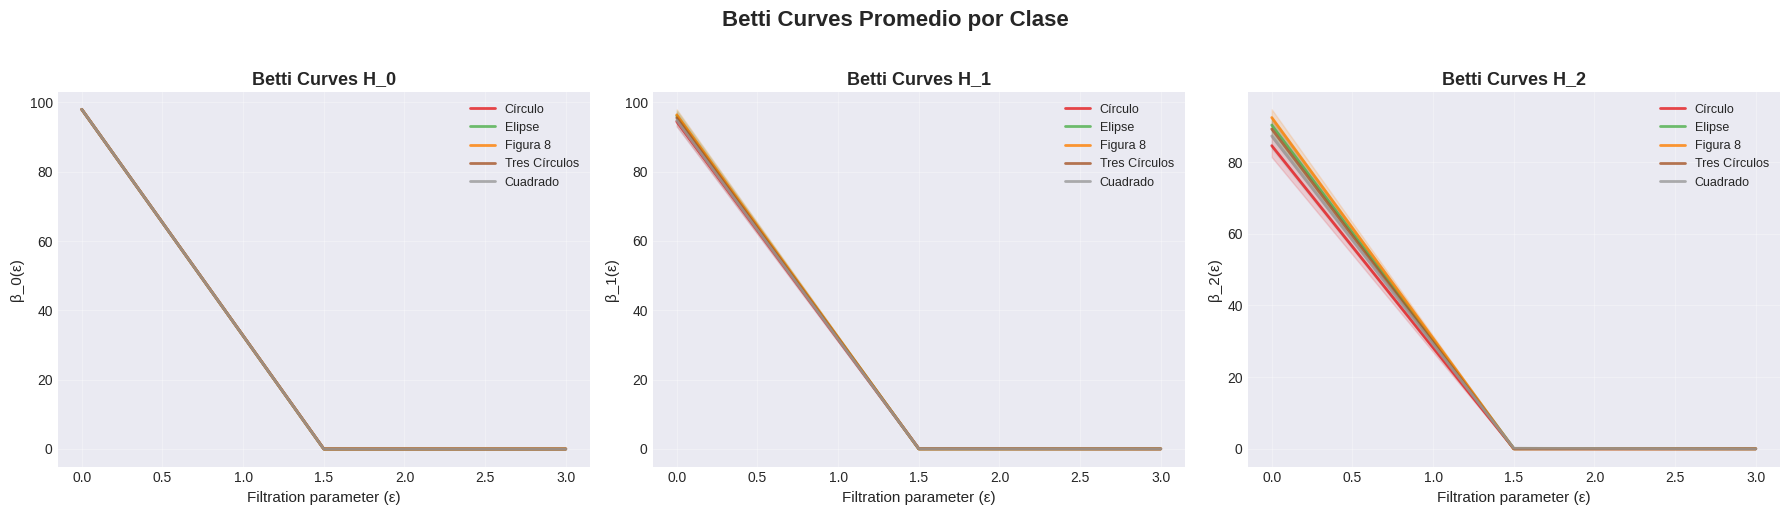


 Features aplanados: (100, 300)

──────────────────────────────────────────────────────────────────────
CLASIFICACIÓN CON BETTI CURVES
──────────────────────────────────────────────────────────────────────

 Accuracy (5-fold CV):
   Media: 0.990
   Std:   0.020
   Scores individuales: [1.   1.   1.   0.95 1.  ]


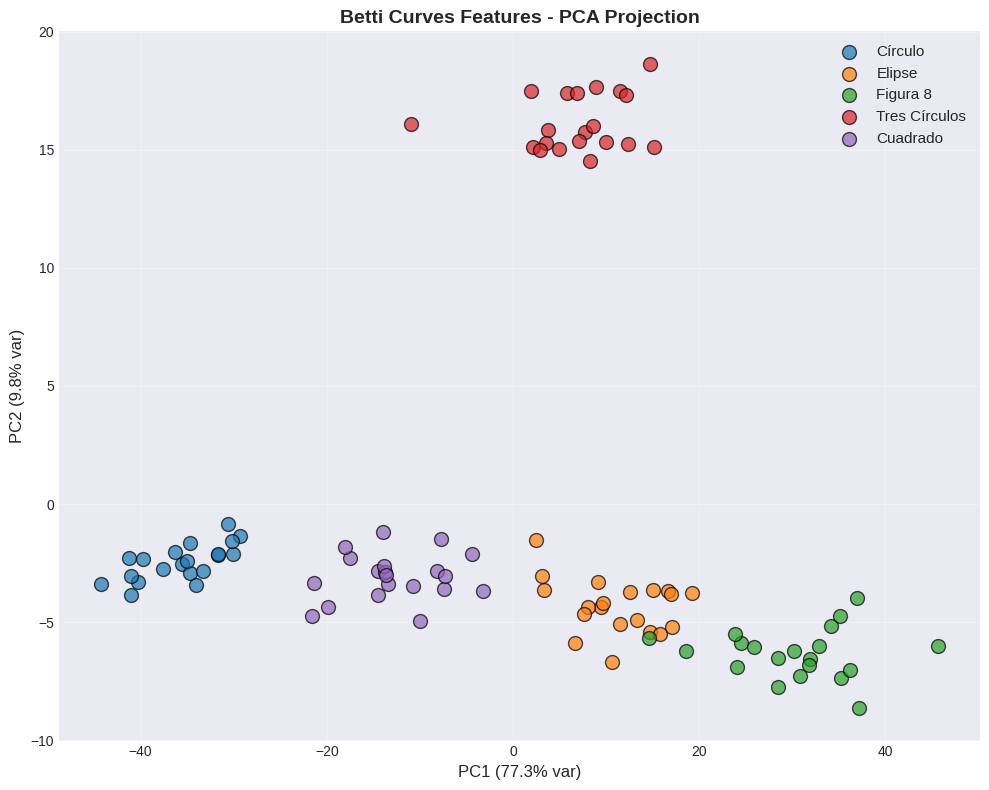

In [19]:
from gtda.diagrams import BettiCurve

# Calcular Betti curves
bc = BettiCurve(n_bins=100)
betti_features = bc.fit_transform(diagrams)

print(f"\n Betti Curves shape: {betti_features.shape}")
print(f"   {betti_features.shape[0]} muestras × {betti_features.shape[1]} dimensiones × {betti_features.shape[2]} bins")

# Visualizar curvas promedio por clase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

samplings = np.linspace(0, 3.0, betti_features.shape[1])
colors = plt.cm.Set1(np.linspace(0, 1, 5))

for dim in range(3):
    ax = axes[dim]

    for class_id, class_name in enumerate(class_names):
        # Promedio de Betti curves para esta clase
        class_betti = betti_features[y == class_id, :, dim]
        mean_betti = class_betti.mean(axis=0)
        std_betti = class_betti.std(axis=0)

        ax.plot(samplings, mean_betti,
               label=class_name,
               color=colors[class_id],
               linewidth=2,
               alpha=0.8)
        ax.fill_between(samplings,
                        mean_betti - std_betti,
                        mean_betti + std_betti,
                        color=colors[class_id],
                        alpha=0.15)

    ax.set_xlabel('Filtration parameter (ε)', fontsize=11)
    ax.set_ylabel(f'β_{dim}(ε)', fontsize=11)
    ax.set_title(f'Betti Curves H_{dim}', fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Betti Curves Promedio por Clase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Aplanar para ML
betti_features_flat = betti_features.reshape(len(betti_features), -1)
print(f"\n Features aplanados: {betti_features_flat.shape}")

# Clasificación con Random Forest
print(f"\n{'─'*70}")
print("CLASIFICACIÓN CON BETTI CURVES")
print(f"{'─'*70}")

clf_betti = RandomForestClassifier(n_estimators=10, random_state=42)
scores_betti = cross_val_score(clf_betti, betti_features_flat, y, cv=5, scoring='accuracy')

print(f"\n Accuracy (5-fold CV):")
print(f"   Media: {scores_betti.mean():.3f}")
print(f"   Std:   {scores_betti.std():.3f}")
print(f"   Scores individuales: {scores_betti}")

# Visualización PCA
pca_betti = PCA(n_components=2)
betti_pca = pca_betti.fit_transform(betti_features_flat)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for class_id, class_name in enumerate(class_names):
    mask = y == class_id
    ax.scatter(betti_pca[mask, 0], betti_pca[mask, 1],
              label=class_name,
            #   color=colors[class_id],
              s=100, alpha=0.7,
              edgecolors='black', linewidth=1)

ax.set_xlabel(f'PC1 ({pca_betti.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_betti.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
ax.set_title('Betti Curves Features - PCA Projection', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
!wget https://raw.githubusercontent.com/gmauricio-toledo/tda-gdl/main/scatterplot3dHTML.py

--2026-03-12 14:26:02--  https://raw.githubusercontent.com/gmauricio-toledo/tda-gdl/main/scatterplot3dHTML.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6327 (6.2K) [text/plain]
Saving to: ‘scatterplot3dHTML.py’

scatterplot3dHTML.p 100%[===================>]   6.18K  --.-KB/s    in 0s      

2026-03-12 14:26:02 (71.8 MB/s) - ‘scatterplot3dHTML.py’ saved [6327/6327]



In [16]:
clases = {k:v[0] for k,v in dataset_generators.items()}
print(clases)
hover_info = [clases[j] for j in y]
print(hover_info[:5])
print(y[:5])

['Círculo', 'Círculo', 'Círculo', 'Círculo', 'Círculo']
[0 0 0 0 0]


Veamos

In [17]:
from scatterplot3dHTML import scatter_plot_3d_plotly

pca_betti = PCA(n_components=3)
betti_pca = pca_betti.fit_transform(betti_features_flat)
scatter_plot_3d_plotly(betti_pca,
                       y,
                       hover_info=hover_info,
                       filename='pca3d_betti.html',
                       fig_title='PCA Betti curves'
                       )

Hover_info limpio. Primeros 3: ['Círculo', 'Círculo', 'Círculo']


In [19]:
print(pca_betti.explained_variance_ratio_)
print(f"Varianza explicada por las primeras 3 componentes: {np.sum(pca_betti.explained_variance_ratio_)}")

[0.77312235 0.09838947 0.04494852]
Varianza explicada por las primeras 3 componentes: 0.9164603376485584


## Landscapes

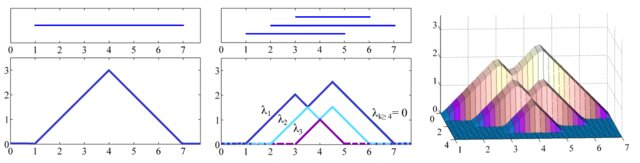

Usaremos la clase [PersistenceLandscape](https://giotto-ai.github.io/gtda-docs/latest/modules/generated/diagrams/representations/gtda.diagrams.PersistenceLandscape.html) de Giotto-TDA


 Landscapes shape: (100, 15, 100)
   100 muestras × 15 features (dims*layers) × 100 bins



 Features aplanados: (100, 1500)

──────────────────────────────────────────────────────────────────────
CLASIFICACIÓN CON PERSISTENCE LANDSCAPES
──────────────────────────────────────────────────────────────────────

 Accuracy (5-fold CV):
   Media: 0.960
   Std:   0.020
   Scores individuales: [0.95 0.95 1.   0.95 0.95]


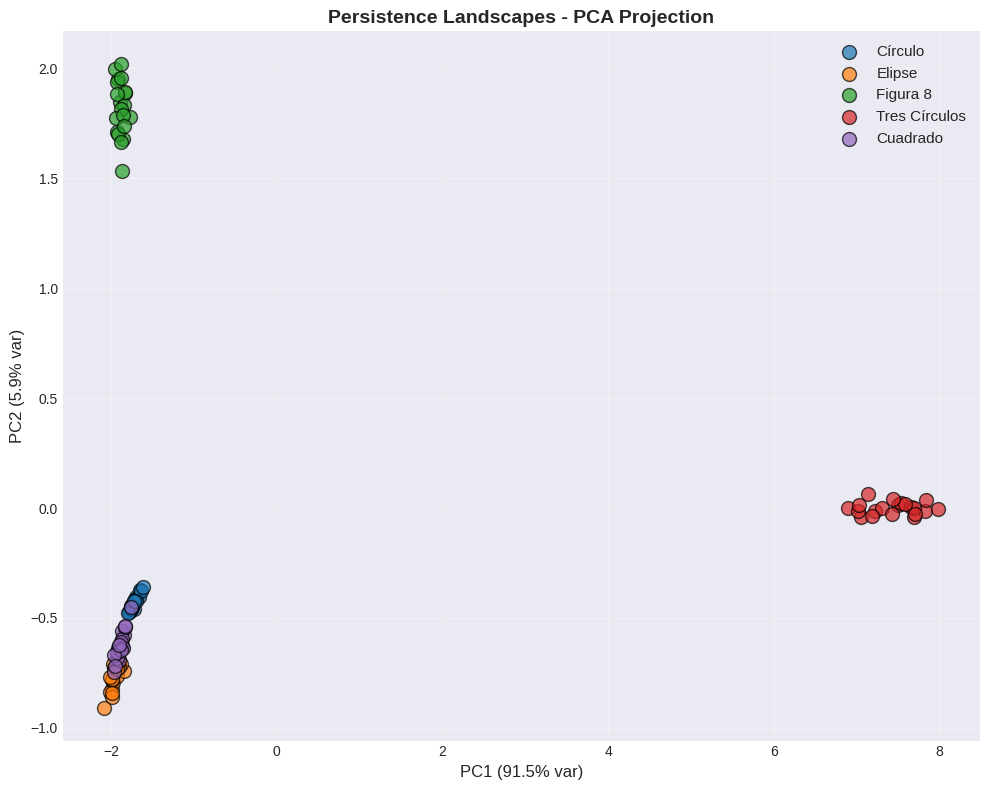

In [20]:
from gtda.diagrams import PersistenceLandscape

# Calcular Persistence Landscapes
pl = PersistenceLandscape(n_layers=5, n_bins=100)
landscape_features = pl.fit_transform(diagrams) # Regresa (n_samples, n_homology_dimensions * n_layers, n_bins)

print(f"\n Landscapes shape: {landscape_features.shape}")
if landscape_features.ndim == 3:
    print(f"   {landscape_features.shape[0]} muestras × {landscape_features.shape[1]} features (dims*layers) × {landscape_features.shape[2]} bins")
else:
    print("No es array de 3 dimensiones")


# Graficar landscapes de H1 del primer elemento de cada clase
for class_id, class_name in enumerate(class_names):
    sample_idx = np.where(y == class_id)[0][0]
    sample_diagram = diagrams[sample_idx:sample_idx+1]

    pl_single = PersistenceLandscape(n_layers=5, n_bins=100)
    At = pl_single.fit_transform(sample_diagram)

    fig = pl_single.plot(At,
                         homology_dimensions=[1]
                         )
    fig.update_layout(title=f'Persistence Landscape — {class_name}')
    fig.show()

# Aplanar para ML
landscape_features_flat = landscape_features.reshape(len(landscape_features), -1)
print(f"\n Features aplanados: {landscape_features_flat.shape}")

# Clasificación
print(f"\n{'─'*70}")
print("CLASIFICACIÓN CON PERSISTENCE LANDSCAPES")
print(f"{'─'*70}")

clf_landscape = RandomForestClassifier(n_estimators=100, random_state=42)
scores_landscape = cross_val_score(clf_landscape, landscape_features_flat, y, cv=5, scoring='accuracy')

print(f"\n Accuracy (5-fold CV):")
print(f"   Media: {scores_landscape.mean():.3f}")
print(f"   Std:   {scores_landscape.std():.3f}")
print(f"   Scores individuales: {scores_landscape}")

# PCA
pca_landscape = PCA(n_components=2)
landscape_pca = pca_landscape.fit_transform(landscape_features_flat)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for class_id, class_name in enumerate(class_names):
    mask = y == class_id
    ax.scatter(landscape_pca[mask, 0], landscape_pca[mask, 1],
              label=class_name,
            #   color=colors[class_id],
              s=100, alpha=0.7,
              edgecolors='black', linewidth=1)

ax.set_xlabel(f'PC1 ({pca_landscape.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_landscape.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
ax.set_title('Persistence Landscapes - PCA Projection', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Imágenes

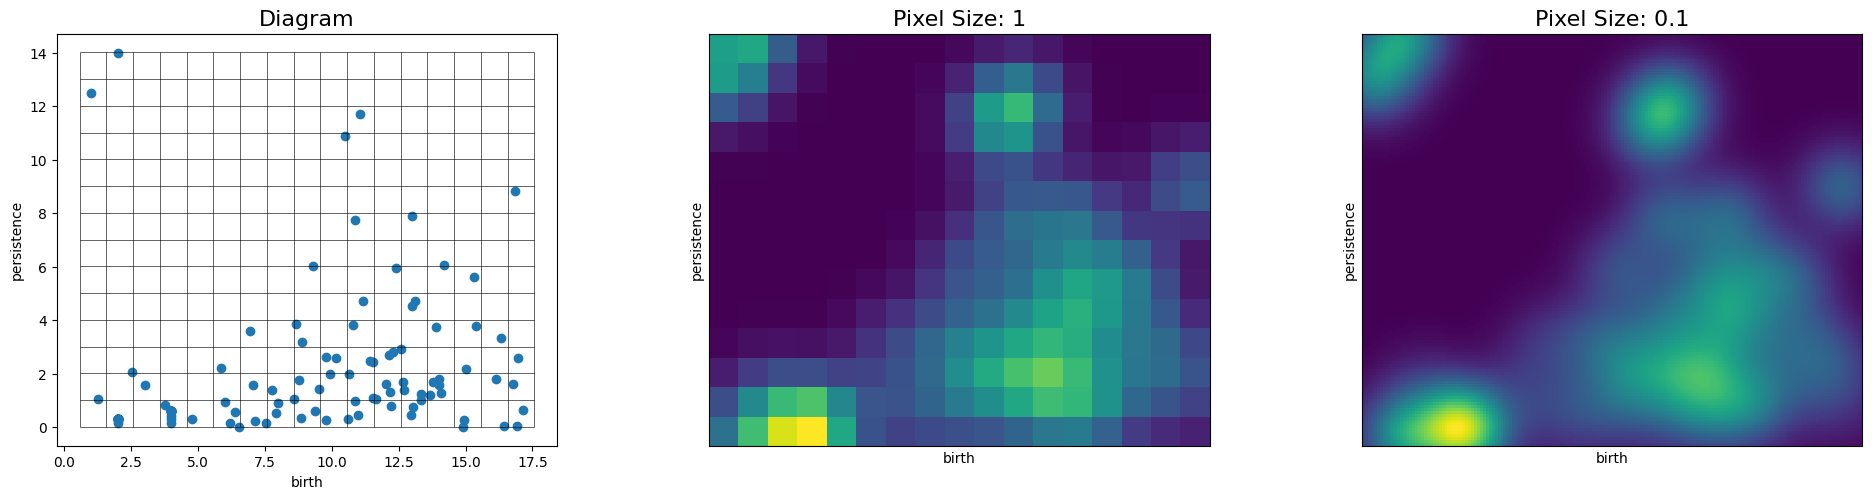


 Persistence Images shape: (100, 3, 20, 20)
   100 muestras × 20 bins × 20 bins × 3 dims


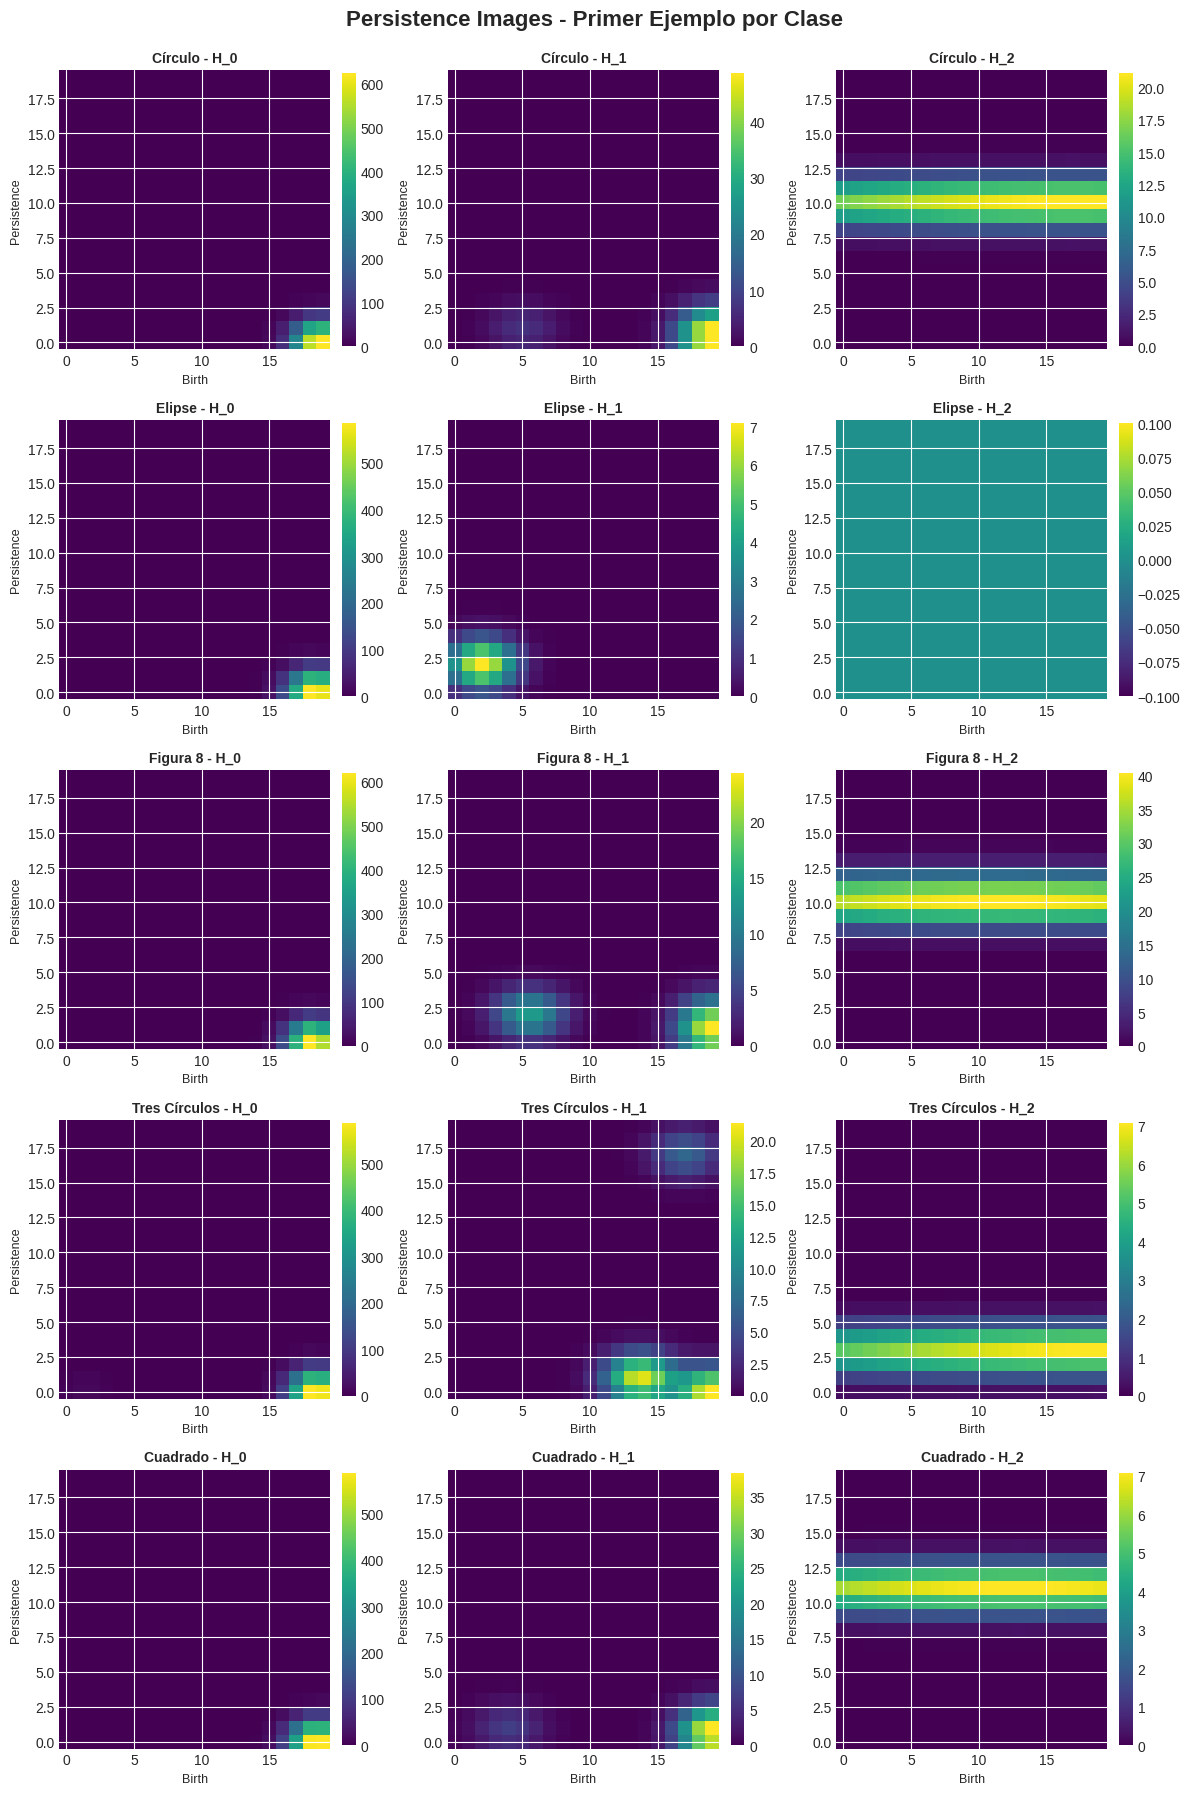


 Features aplanados: (100, 1200)

──────────────────────────────────────────────────────────────────────
CLASIFICACIÓN CON PERSISTENCE IMAGES
──────────────────────────────────────────────────────────────────────

 Accuracy (5-fold CV):
   Media: 0.970
   Std:   0.040
   Scores individuales: [1.   1.   0.95 0.9  1.  ]


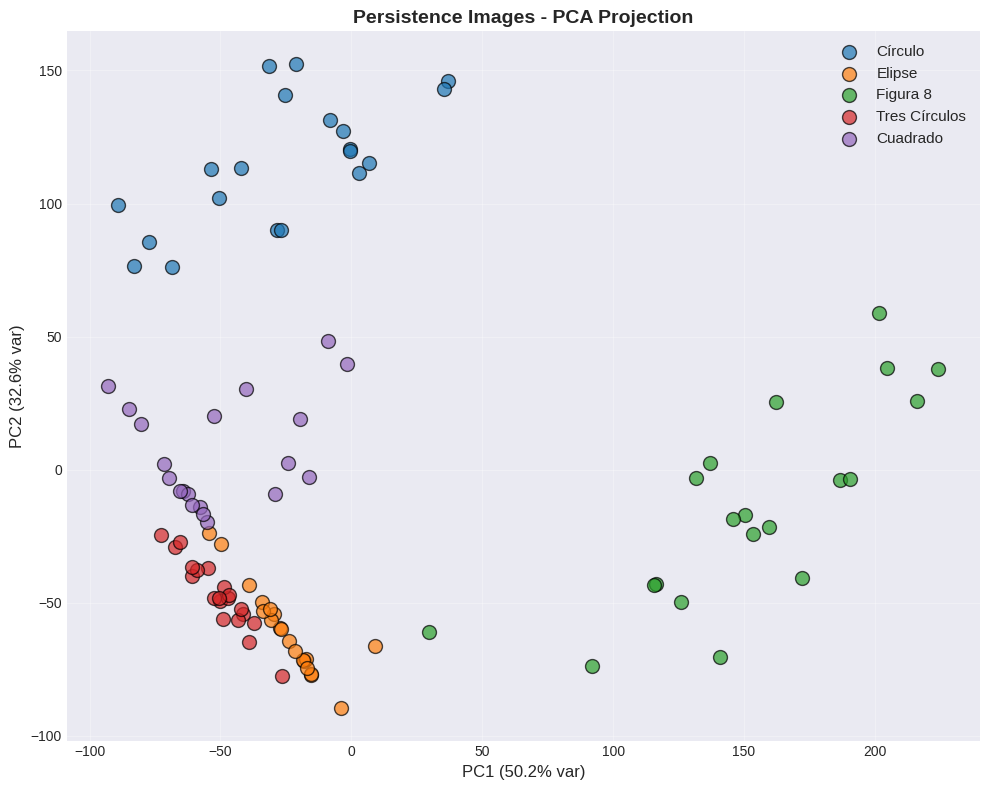

In [21]:
from gtda.diagrams import PersistenceImage

# Calcular Persistence Images
pi = PersistenceImage(sigma=0.15, n_bins=20)
image_features = pi.fit_transform(diagrams)

print(f"\n Persistence Images shape: {image_features.shape}")
print(f"   {image_features.shape[0]} muestras × {image_features.shape[2]} bins × {image_features.shape[3]} bins × {image_features.shape[1]} dims")

# Visualizar primer ejemplo de cada clase
fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for class_id, class_name in enumerate(class_names):
    # Obtener índice del primer elemento de esta clase
    first_idx = np.where(y == class_id)[0][0]
    first_image = image_features[first_idx]

    for dim in range(3):
        ax = axes[class_id, dim]

        # Imagen del primer elemento para esta dimensión
        sample_image = first_image[dim, :, :]

        im = ax.imshow(sample_image.T, origin='lower', cmap='viridis', aspect='auto')
        ax.set_title(f'{class_name} - H_{dim}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Birth', fontsize=9)
        ax.set_ylabel('Persistence', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Persistence Images - Primer Ejemplo por Clase', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Aplanar para ML
image_features_flat = image_features.reshape(len(image_features), -1)
print(f"\n Features aplanados: {image_features_flat.shape}")

# Clasificación
print(f"\n{'─'*70}")
print("CLASIFICACIÓN CON PERSISTENCE IMAGES")
print(f"{'─'*70}")

clf_image = RandomForestClassifier(n_estimators=10, random_state=42)
scores_image = cross_val_score(clf_image, image_features_flat, y, cv=5, scoring='accuracy')

print(f"\n Accuracy (5-fold CV):")
print(f"   Media: {scores_image.mean():.3f}")
print(f"   Std:   {scores_image.std():.3f}")
print(f"   Scores individuales: {scores_image}")

# PCA
pca_image = PCA(n_components=2)
image_pca = pca_image.fit_transform(image_features_flat)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for class_id, class_name in enumerate(class_names):
    mask = y == class_id
    ax.scatter(image_pca[mask, 0], image_pca[mask, 1],
              label=class_name,
            #   color=colors[class_id],
              s=100, alpha=0.7,
              edgecolors='black', linewidth=1)

ax.set_xlabel(f'PC1 ({pca_image.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_image.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
ax.set_title('Persistence Images - PCA Projection', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Entropia de persistencia

[Entropía del diagrama de persistencia](https://giotto-ai.github.io/gtda-docs/latest/theory/glossary.html#persistence-entropy) con la clase [PersistenceEntropy](https://giotto-ai.github.io/gtda-docs/latest/modules/generated/diagrams/features/gtda.diagrams.PersistenceEntropy.html)


 Entropy features shape: (100, 3)
   100 muestras × 3 dimensiones homológicas


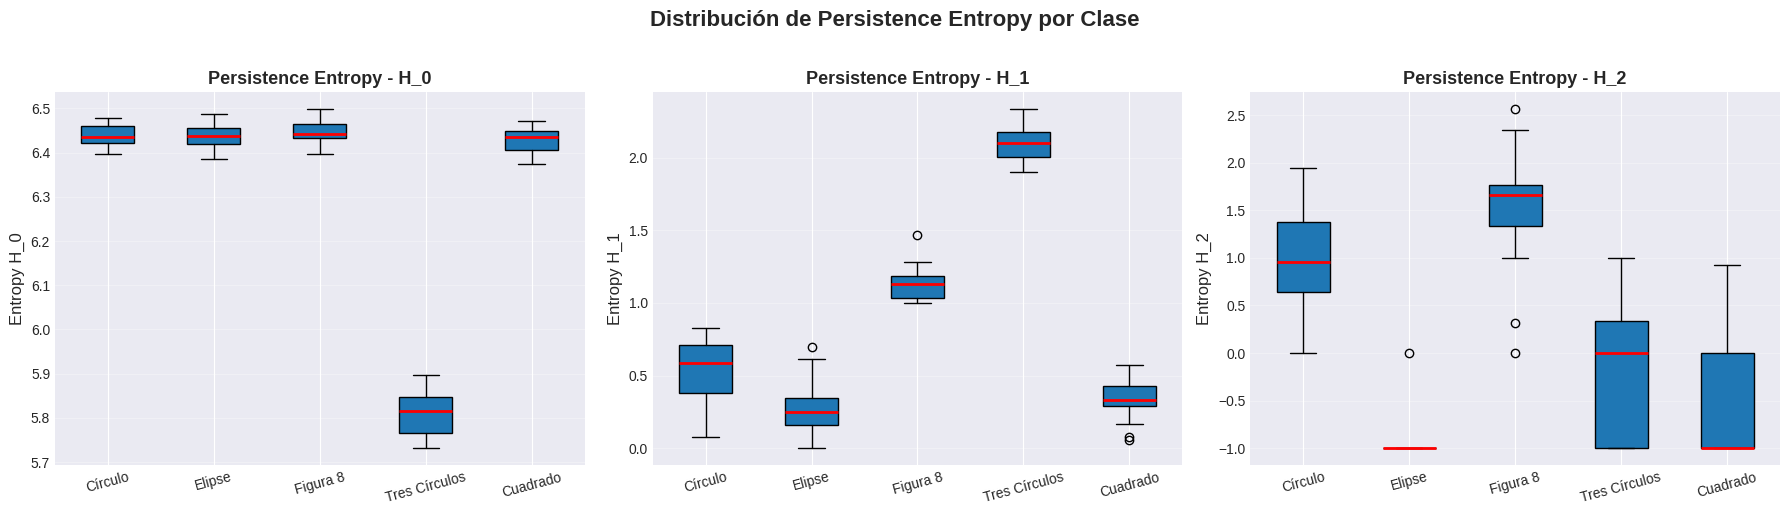


──────────────────────────────────────────────────────────────────────
CLASIFICACIÓN CON PERSISTENCE ENTROPY
──────────────────────────────────────────────────────────────────────

 Accuracy (5-fold CV):
   Media: 0.810
   Std:   0.058
   Scores individuales: [0.75 0.9  0.85 0.75 0.8 ]


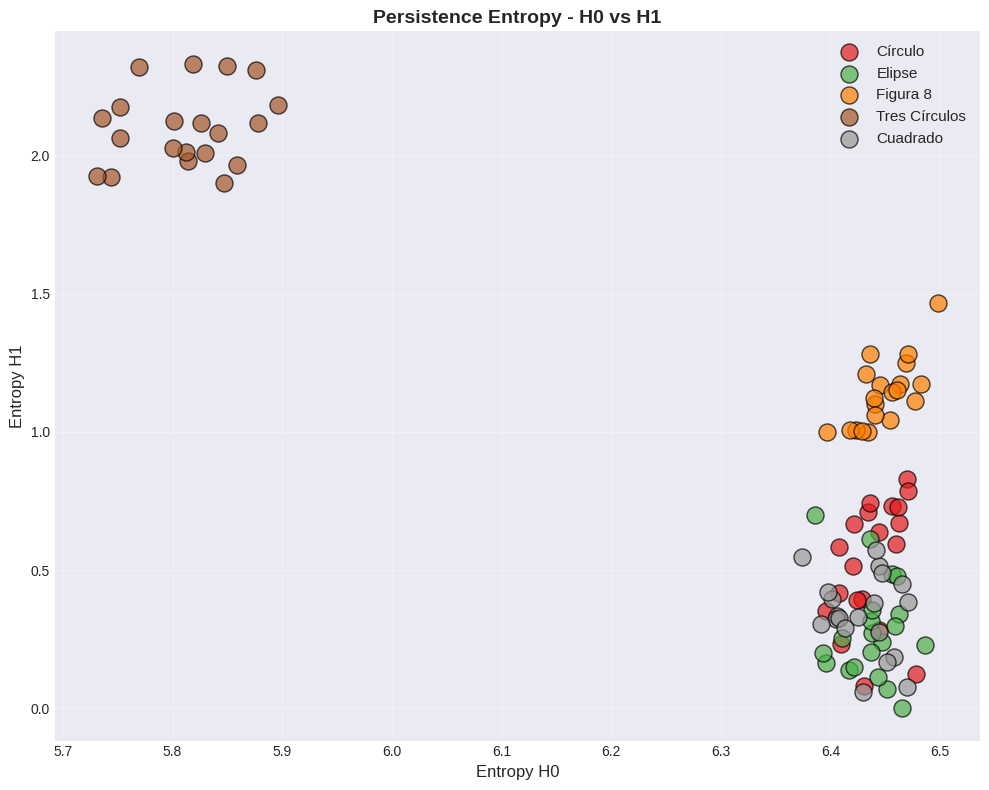

In [26]:
from gtda.diagrams import PersistenceEntropy

# Calcular Persistence Entropy
pe = PersistenceEntropy()
entropy_features = pe.fit_transform(diagrams)

print(f"\n Entropy features shape: {entropy_features.shape}")
print(f"   {entropy_features.shape[0]} muestras × {entropy_features.shape[1]} dimensiones hom.")

# Visualizar entropías por clase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for dim in range(3):
    ax = axes[dim]

    # Box plot por clase
    data_by_class = [entropy_features[y == class_id, dim] for class_id in range(5)]

    bp = ax.boxplot(data_by_class,
                    labels=class_names,
                    patch_artist=True,
                    medianprops=dict(color='red', linewidth=2))

    ax.set_ylabel(f'Entropy H_{dim}', fontsize=12)
    ax.set_title(f'Persistence Entropy - H_{dim}', fontweight='bold', fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Distribución de Persistence Entropy por Clase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Clasificación
print(f"\n{'─'*70}")
print("CLASIFICACIÓN CON PERSISTENCE ENTROPY")
print(f"{'─'*70}")

clf_entropy = RandomForestClassifier(n_estimators=10, random_state=42)
scores_entropy = cross_val_score(clf_entropy, entropy_features, y, cv=5, scoring='accuracy')

print(f"\n Accuracy (5-fold CV):")
print(f"   Media: {scores_entropy.mean():.3f}")
print(f"   Std:   {scores_entropy.std():.3f}")
print(f"   Scores individuales: {scores_entropy}")

# Visualización 2D (solo 3 features, usar las 3)
if entropy_features.shape[1] >= 2:
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    for class_id, class_name in enumerate(class_names):
        mask = y == class_id
        ax.scatter(entropy_features[mask, 0], entropy_features[mask, 1],
                  label=class_name,
                #   color=colors[class_id],
                  s=150, alpha=0.7,
                  edgecolors='black', linewidth=1)

    ax.set_xlabel('Entropy H0', fontsize=12)
    ax.set_ylabel('Entropy H1', fontsize=12)
    ax.set_title('Persistence Entropy - H0 vs H1', fontweight='bold', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Comparación de métodos


COMPARACIÓN COMPLETA DE TODOS LOS MÉTODOS

 RESULTADOS COMPLETOS:
                Método  Dimensión Features  Accuracy Media  Accuracy Std
          Betti Curves                 300            0.99       0.02000
    Persistence Images                1200            0.97       0.04000
Persistence Landscapes                1500            0.96       0.02000
  Top-10 Persistencias                  30            0.91       0.91000
   Persistence Entropy                   3            0.81       0.05831


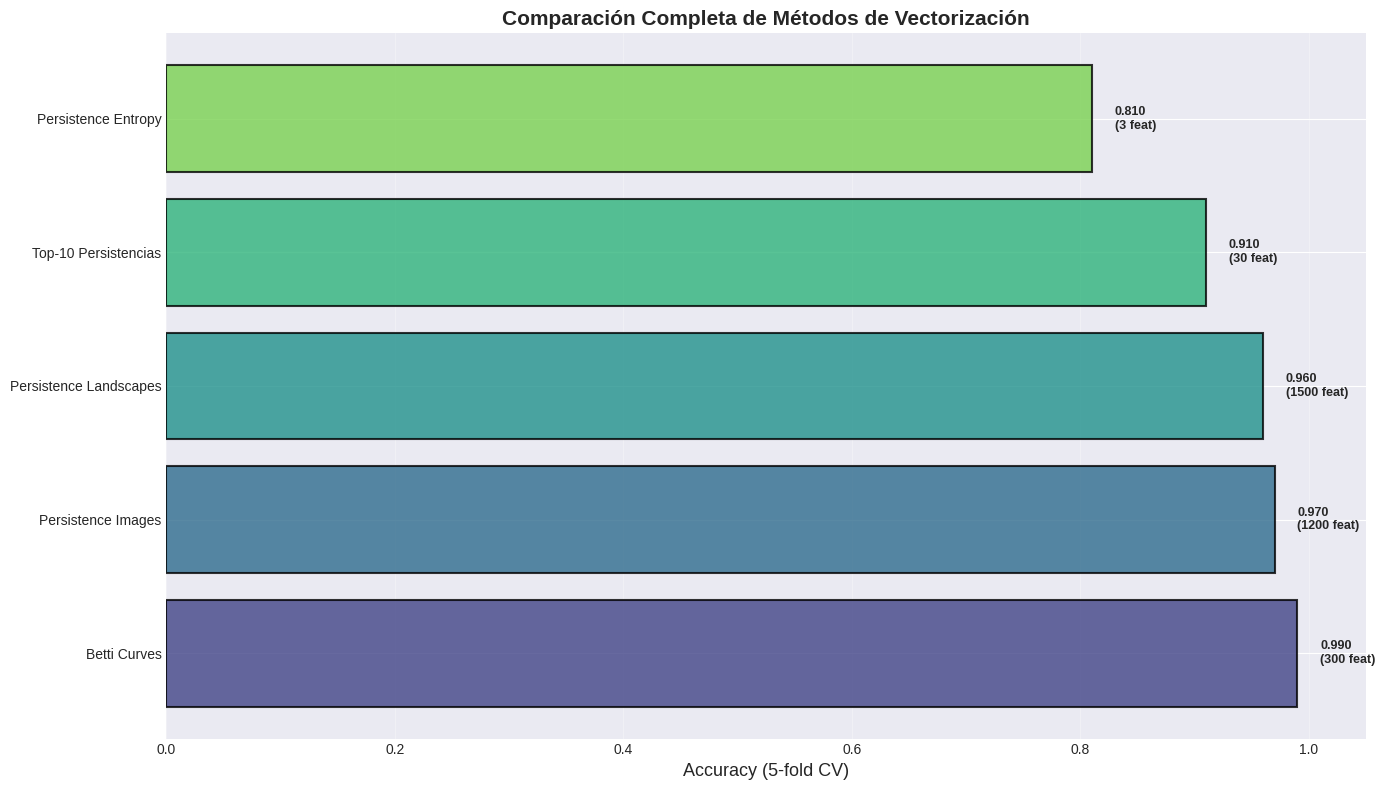

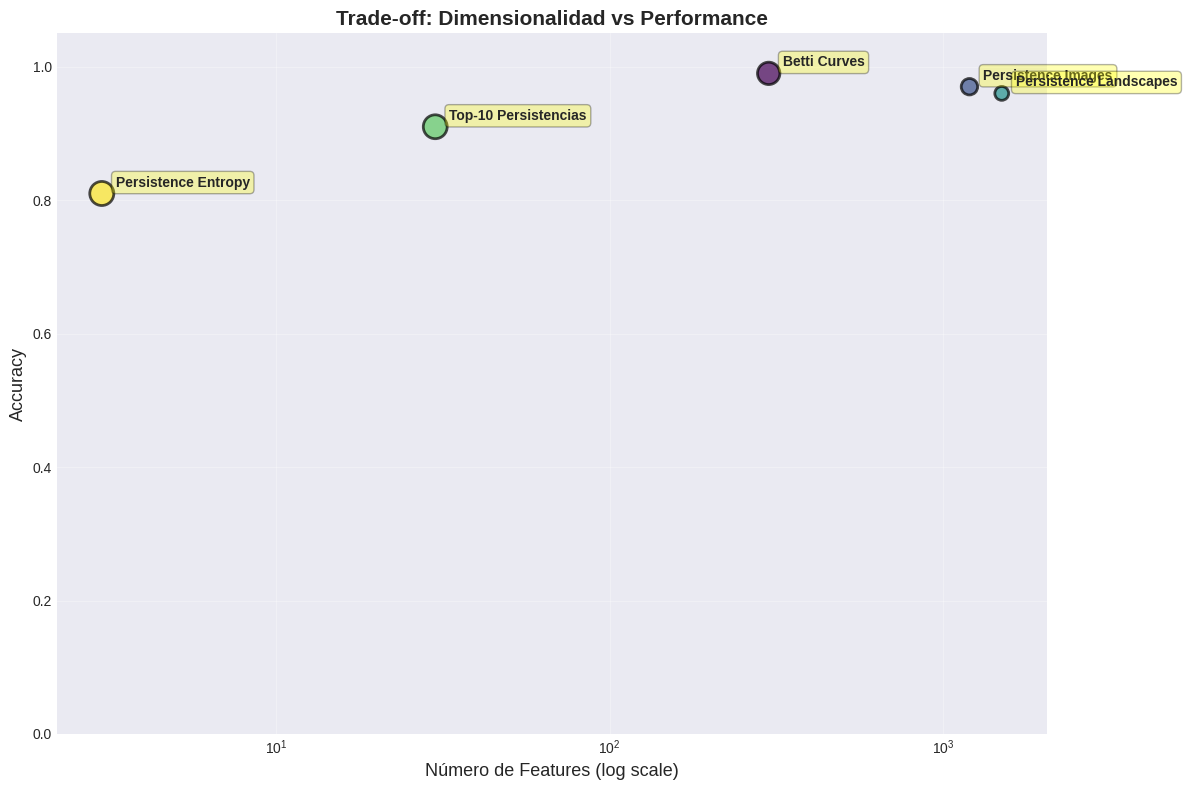

In [25]:
# Organizar resultados en un dataframe
results_updated = pd.DataFrame({
    'Método': [
        'Betti Curves',
        'Persistence Landscapes',
        'Persistence Images',
        'Persistence Entropy',
        'Top-10 Persistencias',
    ],
    'Dimensión Features': [
        betti_features_flat.shape[1],
        landscape_features_flat.shape[1],
        image_features_flat.shape[1],
        entropy_features.shape[1],
        topn_features_selected.shape[1],
    ],
    'Accuracy Media': [
        scores_betti.mean(),
        scores_landscape.mean(),
        scores_image.mean(),
        scores_entropy.mean(),
        topn_results[10]['mean'],
    ],
    'Accuracy Std': [
        scores_betti.std(),
        scores_landscape.std(),
        scores_image.std(),
        scores_entropy.std(),
        topn_results[10]['mean'],
    ]
})

results_updated = results_updated.sort_values('Accuracy Media', ascending=False).reset_index(drop=True)

print("\n RESULTADOS COMPLETOS:")
print(results_updated.to_string(index=False))

# Gráfica comparativa actualizada
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

x_pos = np.arange(len(results_updated))
bars = ax.barh(x_pos, results_updated['Accuracy Media'],
            #   xerr=results_updated['Accuracy Std'],
              capsize=5,
              color=plt.cm.viridis(np.linspace(0.2, 0.8, len(results_updated))),
              edgecolor='black',
              linewidth=1.5,
              alpha=0.8)

ax.set_yticks(x_pos)
ax.set_yticklabels(results_updated['Método'])
ax.set_xlabel('Accuracy (5-fold CV)', fontsize=13)
ax.set_title('Comparación Completa de Métodos de Vectorización',
             fontweight='bold', fontsize=15)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim([0, 1.05])

# Anotar valores y dimensionalidad
for i, (acc, std, dim) in enumerate(zip(results_updated['Accuracy Media'],
                                         results_updated['Accuracy Std'],
                                         results_updated['Dimensión Features'])):
    ax.text(acc + 0.02, i,
           f'{acc:.3f}\n({dim} feat)',
           va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Scatter: Dimensionalidad vs Accuracy
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

sizes = 300 - results_updated['Dimensión Features'] / results_updated['Dimensión Features'].max() * 200

scatter = ax.scatter(results_updated['Dimensión Features'],
                    results_updated['Accuracy Media'],
                    s=sizes,
                    alpha=0.7,
                    c=range(len(results_updated)),
                    cmap='viridis',
                    edgecolors='black',
                    linewidth=2)

# Anotar nombres
for idx, row in results_updated.iterrows():
    ax.annotate(row['Método'],
               (row['Dimensión Features'], row['Accuracy Media']),
               xytext=(10, 5),
               textcoords='offset points',
               fontsize=10,
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3',
                        facecolor='yellow',
                        alpha=0.3))

ax.set_xlabel('Número de Features (log scale)', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Trade-off: Dimensionalidad vs Performance',
            fontweight='bold', fontsize=15)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()